In [1]:
import os
import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import auc, roc_curve, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Find project root and add to sys.path
def find_project_root(start_dir):
    start = Path(start_dir).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists():
            return candidate
    return None

PROJECT_ROOT = find_project_root(os.getcwd())
if PROJECT_ROOT and str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.utils.hybrid_dp_utils import HybridDPCoach
    print("Hybrid DP utilities loaded successfully")
except ImportError:
    print("Warning: src.utils.hybrid_dp_utils not found. Check path.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Paths
from pathlib import Path

def find_project_root(start_dir):
    start = Path(start_dir).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'data').exists() and (candidate / 'src').exists():
            return candidate
    return None

# Colab-first: prefer Drive paths if they exist
colab_candidates = [
    Path('/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots'),
    Path('/content/drive/MyDrive/Hybrid-DP-Approach-For-Mental-Health-Chatbots'),
    Path('/content/drive/MyDrive/content')
 ]
project_root = next((c for c in colab_candidates if c.exists()), None)
PROJECT_ROOT = project_root or find_project_root(Path.cwd()) or Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'go_emotions_dataset.csv'
CLEANED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'go_emotions_cleaned.csv'
MODEL_DIR = Path('/content/drive/MyDrive/content/models/rq1_variants')
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'rq2_rq3_attacks'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'rq2_rq3'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load data
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)

# Merge
df = df_raw.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')
print(f"Dataset: {df.shape}")

Project root: /content/drive/MyDrive/content
Dataset: (209190, 32)


## RQ2: Create 4 Preprocessing Variants

In [4]:
# Identify emotion columns
meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]

# Create 4 preprocessing variants
df['v0_raw'] = df['text'].astype(str).str.lower()
df['v1_masked'] = df['clean_text']

# V2: Length truncation (256 chars)
MAX_LENGTH_V2 = 256
df['v2_length'] = df['text'].astype(str).str.lower().str[:MAX_LENGTH_V2]

# V3: Combined (masked + length)
df['v3_combined'] = df['clean_text'].str[:MAX_LENGTH_V2]

print(" 4 preprocessing variants created")
print(f"  V0 (raw): {df['v0_raw'].str.len().mean():.0f} chars avg")
print(f"  V1 (masked): {df['v1_masked'].str.len().mean():.0f} chars avg")
print(f"  V2 (length): {df['v2_length'].str.len().mean():.0f} chars avg")
print(f"  V3 (combined): {df['v3_combined'].str.len().mean():.0f} chars avg")

 4 preprocessing variants created
  V0 (raw): 70 chars avg
  V1 (masked): 65 chars avg
  V2 (length): 70 chars avg
  V3 (combined): 65 chars avg


## Membership Inference Attack (MIA)

In [5]:
def prepare_mia_data(df, variant_col, emotion_cols, train_ratio=0.7):
    """
    Prepare data for membership inference attack.
    """
    from sklearn.model_selection import train_test_split

    texts = df[variant_col].values
    labels = df[emotion_cols].values.astype(np.float32)

    train_idx, test_idx = train_test_split(
        range(len(df)), test_size=(1-train_ratio), random_state=42
    )

    train_texts = texts[train_idx]
    train_labels = labels[train_idx]
    test_texts = texts[test_idx]
    test_labels = labels[test_idx]

    return {
        'train': (train_texts, train_labels),
        'test': (test_texts, test_labels),
        'train_idx': train_idx,
        'test_idx': test_idx
    }

# Prepare MIA data for each variant
mia_datasets = {}
for variant in ['v0_raw', 'v1_masked', 'v2_length', 'v3_combined']:
    mia_datasets[variant] = prepare_mia_data(df, variant, emotion_cols)
    print(f" MIA data prepared for {variant}")

 MIA data prepared for v0_raw
 MIA data prepared for v1_masked
 MIA data prepared for v2_length
 MIA data prepared for v3_combined


## MIA: Extract Model Confidence Scores

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = torch.FloatTensor(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': self.labels[idx]
        }

def extract_mia_scores(model_name, tokenizer, model, train_data, test_data):
    """
    Extract confidence scores (max prob) for all samples.
    MIA: Train samples should have higher confidence if overfitted.
    """
    model.eval()

    train_texts, train_labels = train_data
    test_texts, test_labels = test_data

    train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
    test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16)
    test_loader = DataLoader(test_dataset, batch_size=16)

    train_scores = []
    test_scores = []

    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')

    with torch.no_grad():
        # Train set confidence
        for batch in tqdm(train_loader, desc=f'Extracting {model_name} train scores'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if logits.shape[1] != labels.shape[1]:
                labels = labels[:, :logits.shape[1]]

            losses = loss_fn(logits, labels).mean(dim=1)
            train_scores.extend(losses.cpu().numpy())

        # Test set confidence
        for batch in tqdm(test_loader, desc=f'Extracting {model_name} test scores'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if logits.shape[1] != labels.shape[1]:
                labels = labels[:, :logits.shape[1]]

            losses = loss_fn(logits, labels).mean(dim=1)
            test_scores.extend(losses.cpu().numpy())

    return np.array(train_scores), np.array(test_scores)

print(" MIA score extraction function ready")

 MIA score extraction function ready


## Load Pre-trained Models from RQ1 and Perform MIA

In [7]:
# Map variants to RQ1 model names (pt fallback)
variant_to_model = {
    'v0_raw': 'V0_BASELINE_best.pt',
    'v1_masked': 'V1_ANONYM_best.pt',
    'v2_length': 'V2_DP_SGD_best.pt',
    'v3_combined': 'V3_HYBRID_best.pt'
}

# Prefer HuggingFace-style checkpoints if available
RQ2_MODELS_ROOT = Path('/content/drive/MyDrive/content/models_rq2')
variant_dir_candidates = {
    'v0_raw': ['v0_baseline'],
    'v1_masked': ['v1_anonym', 'v1_masked'],
    'v2_length': ['v2_dp_sgd', 'v2_length'],
    'v3_combined': ['v3_hybrid', 'v3_combined']
}

def get_latest_checkpoint_dir(base_dir):
    if not base_dir.exists():
        return None
    checkpoints = []
    for p in base_dir.glob('checkpoint-*'):
        try:
            step = int(p.name.split('-')[1])
            checkpoints.append((step, p))
        except Exception:
            continue
    if not checkpoints:
        return None
    return sorted(checkpoints, key=lambda x: x[0])[-1][1]

def resolve_checkpoint_dir(variant):
    for name in variant_dir_candidates.get(variant, []):
        base = RQ2_MODELS_ROOT / name
        ckpt = get_latest_checkpoint_dir(base)
        if ckpt is not None:
            return ckpt
    return None

def load_model_and_tokenizer(model_ref):
    if model_ref is None:
        return None, None, None
    model_ref = Path(model_ref)
    if model_ref.is_dir():
        tokenizer = AutoTokenizer.from_pretrained(model_ref)
        model = AutoModelForSequenceClassification.from_pretrained(model_ref)
        return model, tokenizer, model.config.num_labels
    if model_ref.is_file():
        state_dict = torch.load(model_ref, map_location=device)
        num_labels = state_dict.get('classifier.out_proj.weight', torch.zeros(len(emotion_cols))).shape[0]
        tokenizer = AutoTokenizer.from_pretrained('roberta-base')
        model = AutoModelForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=num_labels, problem_type='multi_label_classification'
        )
        model.load_state_dict(state_dict, strict=False)
        return model, tokenizer, num_labels
    return None, None, None

# Perform MIA for each variant
mia_results_all = []
missing_models = []

print(f"Model dir: {MODEL_DIR}")

for variant, model_file in variant_to_model.items():
    print(f"\nPerforming MIA on {variant}...")
    model_ref = resolve_checkpoint_dir(variant)
    if model_ref is None:
        model_ref = Path(MODEL_DIR) / model_file
    if not Path(model_ref).exists():
        print(f"  Model not found: {model_ref}")
        missing_models.append(str(model_ref))
        continue

    model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
    if model is None:
        continue
    model.to(device)

    train_texts, train_labels = mia_datasets[variant]['train']
    test_texts, test_labels = mia_datasets[variant]['test']

    train_scores, test_scores = extract_mia_scores(
        variant, tokenizer, model, (train_texts, train_labels), (test_texts, test_labels)
    )

    y_true = np.concatenate([np.ones(len(train_scores)), np.zeros(len(test_scores))])
    y_score = np.concatenate([-train_scores, -test_scores])

    mia_auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    mia_results_all.append({
        'variant': variant, 'mia_auc': mia_auc,
        'train_scores': train_scores, 'test_scores': test_scores,
        'fpr': fpr, 'tpr': tpr
    })
    print(f"  MIA AUC: {mia_auc:.4f}")

if mia_results_all:
    mia_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['train_scores', 'test_scores', 'fpr', 'tpr']} for r in mia_results_all])
    mia_df.to_csv(os.path.join(REPORT_DIR, 'rq3_mia_results.csv'), index=False)

Model dir: /content/drive/MyDrive/content/models/rq1_variants

Performing MIA on v0_raw...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v2_length test scores: 100%|██████████| 3923/3923 [02:02<00:00, 32.09it/s]


  MIA AUC: 0.4974

Performing MIA on v3_combined...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v3_combined test scores: 100%|██████████| 3923/3923 [02:01<00:00, 32.30it/s]


  MIA AUC: 0.5002


## Canary Insertion Attack

In [8]:
def canary_insertion_attack(df, variant_col, emotion_cols, tokenizer, model, num_canaries=50):
    """
    Inject canary samples and test if they have lower loss.
    """
    canary_texts = [f"[CANARY_{i}] this is a test sentence about emotions" for i in range(num_canaries)]
    canary_labels = np.zeros((num_canaries, len(emotion_cols)))
    canary_labels[:, 0] = 1

    non_canary_idx = np.random.choice(len(df), num_canaries, replace=False)
    non_canary_texts = df[variant_col].iloc[non_canary_idx].values
    non_canary_labels = df[emotion_cols].iloc[non_canary_idx].values.astype(np.float32)

    model.eval()
    dataset_canary = EmotionDataset(canary_texts, canary_labels, tokenizer)
    dataset_non_canary = EmotionDataset(non_canary_texts, non_canary_labels, tokenizer)

    loader_canary = DataLoader(dataset_canary, batch_size=16)
    loader_non_canary = DataLoader(dataset_non_canary, batch_size=16)

    canary_losses = []
    non_canary_losses = []

    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')

    with torch.no_grad():
        for batch in loader_canary:
            outputs = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            labels = batch['labels'].to(device)
            if outputs.logits.shape[1] != labels.shape[1]: labels = labels[:, :outputs.logits.shape[1]]
            losses = loss_fn(outputs.logits, labels).mean(dim=1)
            canary_losses.extend(losses.cpu().numpy())

        for batch in loader_non_canary:
            outputs = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            labels = batch['labels'].to(device)
            if outputs.logits.shape[1] != labels.shape[1]: labels = labels[:, :outputs.logits.shape[1]]
            losses = loss_fn(outputs.logits, labels).mean(dim=1)
            non_canary_losses.extend(losses.cpu().numpy())

    canary_losses = np.array(canary_losses)
    non_canary_losses = np.array(non_canary_losses)
    canary_detection_rate = (canary_losses < non_canary_losses.mean()).sum() / len(canary_losses)

    return {'canary_mean_loss': canary_losses.mean(), 'non_canary_mean_loss': non_canary_losses.mean(), 'canary_detection_rate': canary_detection_rate}

## Execute Canary Attacks

In [9]:
canary_results_all = []
for variant, model_file in variant_to_model.items():
    print(f"\nCanary attack on {variant}...")
    model_ref = resolve_checkpoint_dir(variant) or (Path(MODEL_DIR) / model_file)
    if not Path(model_ref).exists(): continue

    model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
    if model is None: continue
    model.to(device)

    res = canary_insertion_attack(df, variant, emotion_cols, tokenizer, model)
    res['variant'] = variant
    canary_results_all.append(res)
    print(f"  Detection rate: {res['canary_detection_rate']:.2%}")

if canary_results_all:
    pd.DataFrame(canary_results_all).to_csv(os.path.join(REPORT_DIR, 'rq3_canary_results.csv'), index=False)


Canary attack on v0_raw...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 58.00%

Canary attack on v1_masked...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 100.00%

Canary attack on v3_combined...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 0.00%


## Visualize RQ2/RQ3 Results

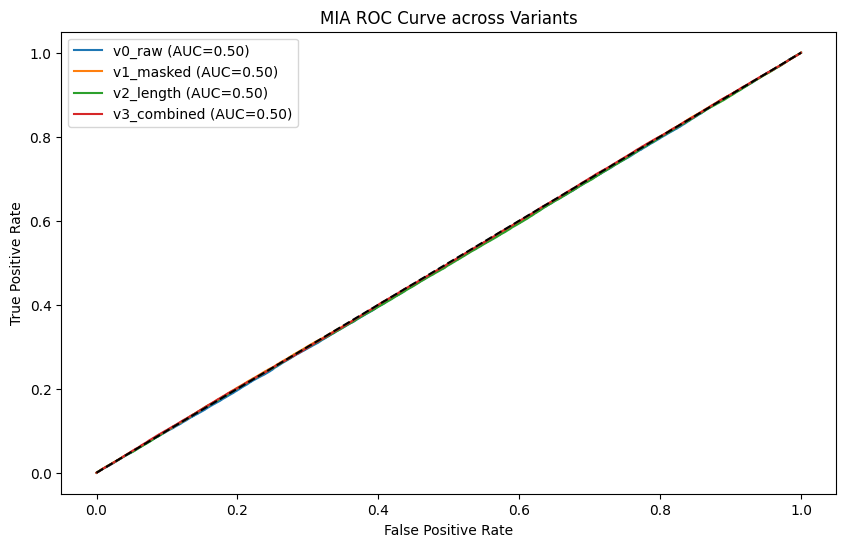

In [10]:
if mia_results_all:
    plt.figure(figsize=(10, 6))
    for r in mia_results_all:
        plt.plot(r['fpr'], r['tpr'], label=f"{r['variant']} (AUC={r['mia_auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('MIA ROC Curve across Variants')
    plt.legend()
    plt.show()